# 5 Key Understandings to take away from Ridge Regression

- As we know by know, that in RR we add a regularization term to the cost function and uss added term ki wajah se overfitting kam ho jata hai(the value of weights are reduced)

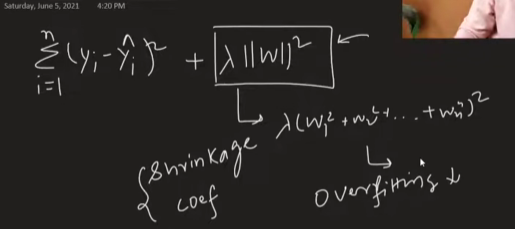

- Following are the 5 key understandings we will discuss:
    1. How the coefficients get affected?
    2. Higher coefficients get penalized more
    3. Bias-Variance Tradeoff
    4. Contour plots
    5. Why called Ridge?

## 1. How are coefficients affected?

### You increare the $\lambda$ value, how do the coefficients get affected?

- As we increase the value of $\lambda$, the coefficients shrinks towards zero, but they never become exactly zero. 

### <span style="color:#1F4E79;">Why don't the coefficients become exactly zero?</span>

<span style="color:#2F5597;"><strong>This follows from the geometry of regularization.</strong></span>

## <span style="color:#0B6E4F;">What is a norm?</span>

A norm measures the size (length) of a vector.

For weights $\mathbf{w} = (w_1, w_2, \dots, w_n)$, we can treat $\mathbf{w}$ as a point vector in $n$-dimensional space.

Two common norms in regularization are:

- <span style="color:#8A4FFF;"><strong>L1 norm (Lasso)</strong></span>:
  $$
  ||\mathbf{w}||_1 = \sum |w_i|
  $$

- <span style="color:#1D70B8;"><strong>L2 norm (Ridge)</strong></span>:
  $$
  ||\mathbf{w}||_2 = \sqrt{\sum w_i^2}
  $$

<span style="color:#7A3E00;"><strong>Intuition:</strong></span> L1 corresponds to Manhattan distance, and L2 corresponds to Euclidean distance.

Reference: https://youtu.be/FiSy6zWDfiA?si=tGdqMi0x2SUGMUZU

---

## <span style="color:#0B6E4F;">Penalized form vs constrained form</span>

### <span style="color:#1F4E79;">Penalized form (used in regression)</span>

$$
\min_{\mathbf{w}} \; \underbrace{\sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2}_{\text{Data fitting (Loss)}} \;+\; \lambda \underbrace{||\mathbf{w}||_p}_{\text{Penalty on weights}}
$$

- The first term ensures the model fits the data well.
- The second term penalizes large weights.

<span style="color:#7A3E00;"><strong>Types of penalties:</strong></span>

- <span style="color:#1D70B8;"><strong>Ridge (L2)</strong></span>:
  $$
  ||\mathbf{w}||_2^2 = \sum_{j=1}^{d} w_j^2
  $$
  This smoothly penalizes large magnitudes.

- <span style="color:#8A4FFF;"><strong>Lasso (L1)</strong></span>:
  $$
  ||\mathbf{w}||_1 = \sum_{j=1}^{d} |w_j|
  $$
  This encourages sparsity by penalizing absolute values.

---

### <span style="color:#1F4E79;">Constrained form (geometric view)</span>

$$
\min_{\mathbf{w}} \; \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2
\quad \text{s.t.} \quad ||\mathbf{w}||_p \le t
$$

- Instead of adding a penalty, we directly restrict the size of weights.
- The solution must lie inside a norm ball.

---

### <span style="color:#B3541E;">Key insight</span>

Both formulations are mathematically equivalent:

$$
\min \; \text{Loss} + \lambda ||\mathbf{w}|| 
\quad \Longleftrightarrow \quad
\min \; \text{Loss} \;\; \text{s.t.} \;\; ||\mathbf{w}|| \le t
$$

Relationship between the two controls:

$$
\lambda \uparrow \;\Longleftrightarrow\; t \downarrow
$$

> <span style="color:#B3541E;"><strong>A stronger penalty means a tighter constraint.</strong></span>

---

## <span style="color:#0B6E4F;">Why discuss penalized and constrained forms?</span>

In practice, regression is usually written in penalized form:

$$
\min_{\mathbf{w}} \; \text{Loss}(\mathbf{w}) + \lambda ||\mathbf{w}||
$$

However, this form does not provide clear geometric intuition.

To understand why Ridge rarely gives exact zeros, we use the constrained form:

$$
\min_{\mathbf{w}} \; \text{Loss}(\mathbf{w})
\quad \text{s.t.} \quad ||\mathbf{w}|| \le t
$$

This gives a visual interpretation in terms of norms, shapes, and optimization geometry.

---

## <span style="color:#0B6E4F;">What happens during optimization?</span>

- The loss function creates contour lines (typically ellipses).
- The constraint defines a feasible region (norm ball).

<span style="color:#2F5597;"><strong>Optimization moves to lower and lower contours until the contour first touches the constraint boundary.</strong></span>

> <span style="color:#2F5597;"><strong>That first touching point is the optimal solution.</strong></span>

---

## <span style="color:#0B6E4F;">Why Ridge weights usually do not become exactly zero</span>

Using the constrained form:

$$
\min_{\mathbf{w}} \; \text{Loss}(\mathbf{w})
\quad \text{s.t.} \quad ||\mathbf{w}|| \le t
$$

Figure interpretation:

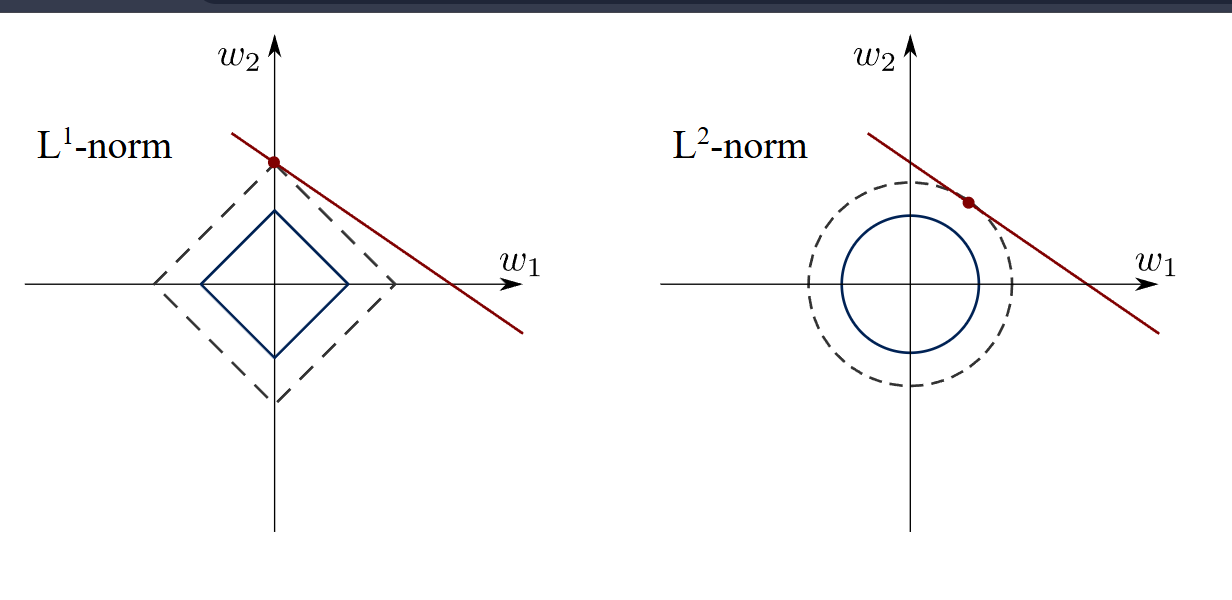

- Red line: loss contour.
- Blue shape: constraint region from the norm.
- Red point: optimal solution.

Again, optimization stops at the first contact between contour and boundary.

---

## <span style="color:#8A4FFF;">L1 norm (Lasso)</span>

$$
||\mathbf{w}||_1 = |w_1| + |w_2|
$$

- Shape: diamond.
- It has sharp corners on the axes.

<span style="color:#7A3E00;"><strong>Key observation:</strong></span>

- The optimum often occurs at a corner.
- Corners lie on axes, so one coordinate can be zero:
  $$
  w_1 = 0 \quad \text{or} \quad w_2 = 0
  $$

> <span style="color:#0B6E4F;"><strong>Result: some weights become exactly zero, producing sparse solutions.</strong></span>

---

## <span style="color:#1D70B8;">L2 norm (Ridge)</span>

$$
||\mathbf{w}||_2^2 = w_1^2 + w_2^2
$$

- Shape: circle.
- The boundary is smooth, with no sharp corners.

<span style="color:#7A3E00;"><strong>Key observation:</strong></span>

- The optimum lies on a smooth boundary.
- A smooth boundary is generally not aligned with coordinate axes.

<span style="color:#C0392B;"><strong>Result:</strong></span> weights shrink continuously, but typically
$$
w_j \neq 0
$$

---

## <span style="color:#B3541E;">Important note</span>

In theory, Ridge can produce a zero weight if the loss contour is perfectly aligned with an axis.

In real datasets, contours are usually tilted ellipses, so that perfect alignment is extremely unlikely.

Also, a zero coefficient implies a feature has no contribution at all, which is a strict condition.

<span style="color:#2F5597;"><strong>So in practice, Ridge almost never produces exact zero coefficients.</strong></span>

---

## <span style="color:#B3541E;">Final intuition</span>

- <span style="color:#8A4FFF;"><strong>L1</strong></span> has corners, so solutions can land on axes and produce exact zeros.
- <span style="color:#1D70B8;"><strong>L2</strong></span> has a smooth boundary, so coefficients are usually shrunk but not forced to zero.


In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
data = load_diabetes()

In [3]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.shape

(442, 11)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [7]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [8]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))
    

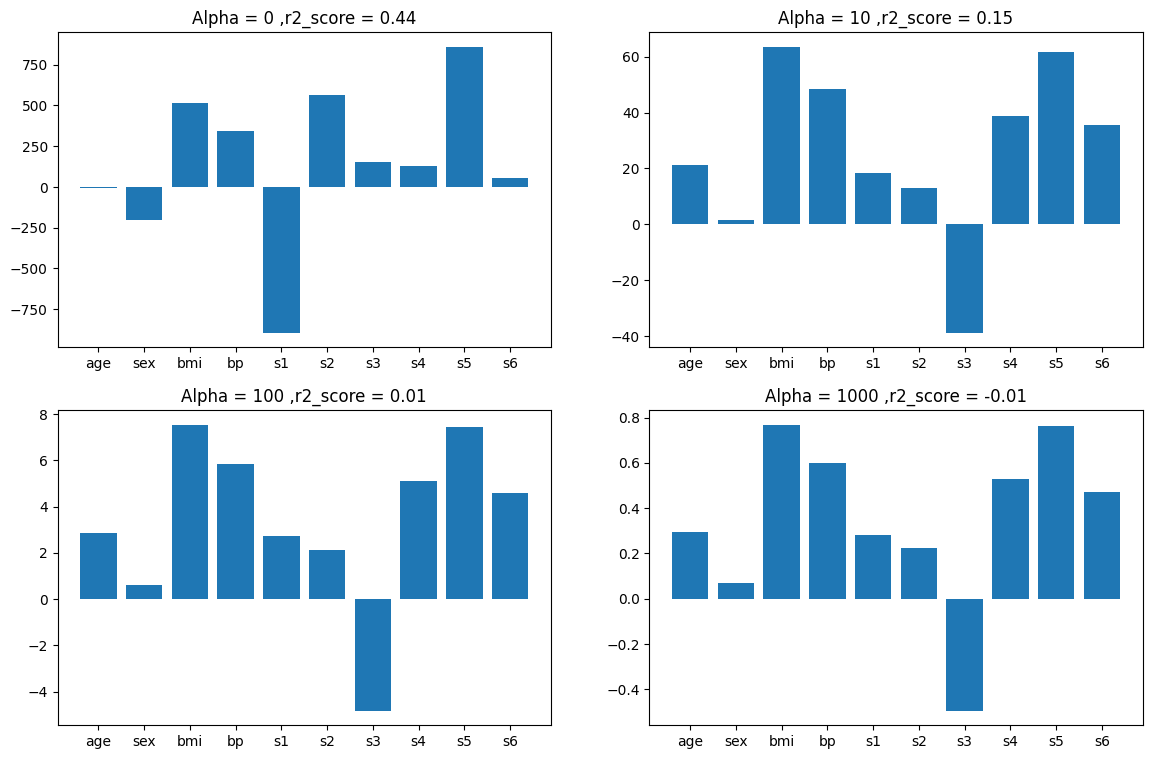

In [9]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

- See the y-axis in the above graph, as we increase th $\lambda$ , the value of coefficients are approachin to 0

## 2. Higher Coefficients are affected more

- As we increase the value of $\lambda$, the higher coefficients are penalized more, and they shrink faster than smaller coefficients.

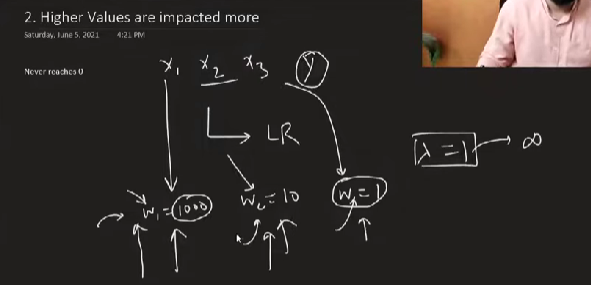

In [10]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [11]:
input_array = np.array(coefs)

In [12]:
coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [13]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [14]:
input_array = np.array(coefs).T

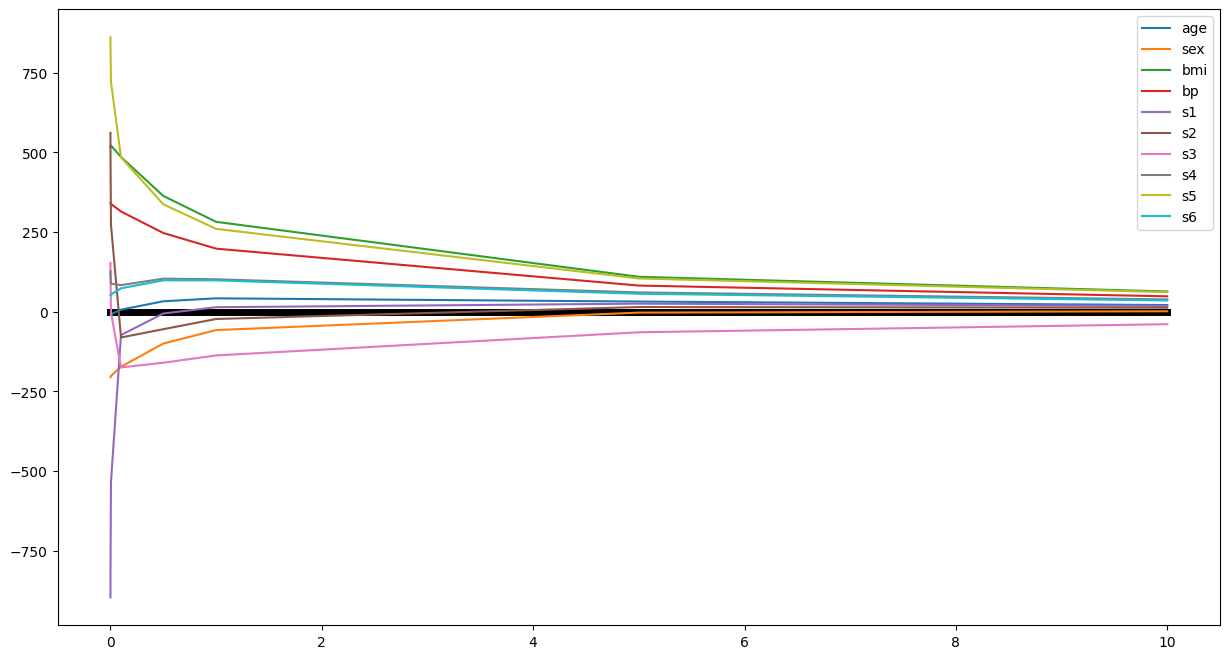

In [15]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

- You can see the the above plot, the weights with higher magnitude, like s5 (yellow line) is shrinking faster than the weights with smaller magnitude, like age (blue line) as we increase the value of $\lambda$.

- And also see with increasing $\lambda$, the weights are shrinking towards zero (black line), but they never become exactly zero.

## 3. Impact of regularization on Bias and Variance

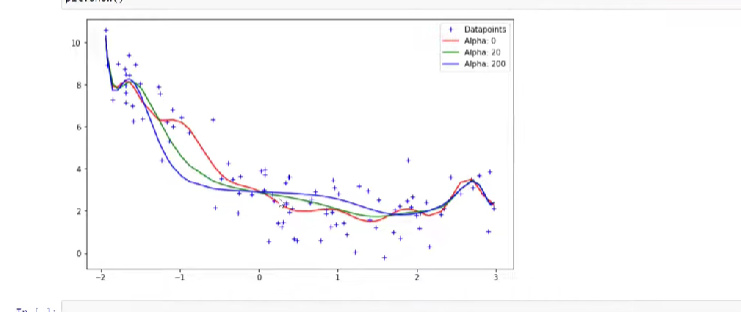

- we saw this example in earlier lessons as well, that we are trying to fit a degree 16 polynomial on degree 2 data, so it was overfitting, then we applied Ridge regularization, and as we increase the value of $\lambda$, the model becomes less complex, and it is underfitting the data. So with increasing $\lambda$, the bias is increasing and variance is decreasing.

- But for $\lambda = 200$ it is underfitting the data, so the bias is very high which we don't want, so we need to find a sweet spot for $\lambda$ where the bias and variance are balanced.

In [27]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from mlxtend.evaluate import bias_variance_decomp

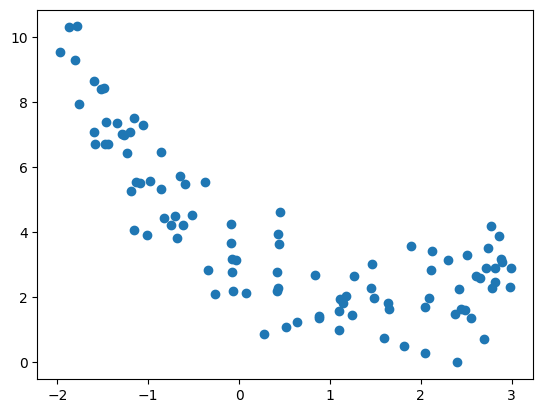

In [28]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [30]:
alphas = np.linspace(0, 30, 100)

loss = []
bias = []
variance = []

for alpha in alphas:
    
    # Pipeline = Polynomial + Scaling + Ridge
    model = make_pipeline(
        PolynomialFeatures(degree=15),
        StandardScaler(),
        Ridge(alpha=alpha)
    )

    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        model,
        X_train, y_train,
        X_test, y_test,
        loss='mse',
        random_seed=123
    )

    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

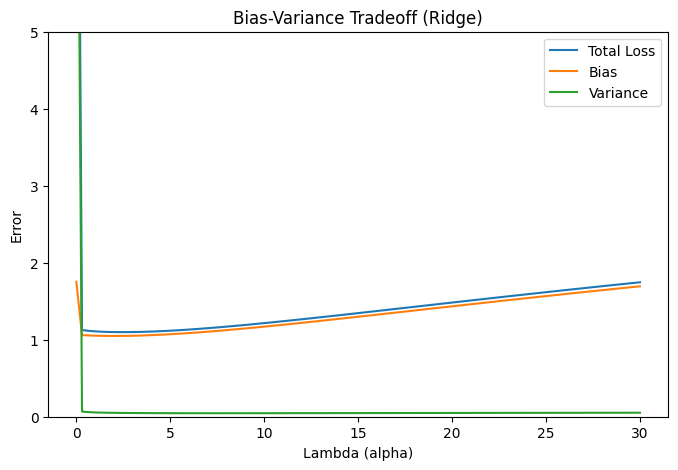

In [31]:
plt.figure(figsize=(8,5))
plt.plot(alphas, loss, label='Total Loss')
plt.plot(alphas, bias, label='Bias')
plt.plot(alphas, variance, label='Variance')

plt.xlabel('Lambda (alpha)')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff (Ridge)')
plt.ylim(0, 5)
plt.legend()
plt.show()

- so, you can see as we increase the value of $\lambda$, the bias is increasing and variance is decreasing, so we need to find a sweet spot for $\lambda$ where the bias and variance are balanced.

- The Total loss is sum of bias, variance and irreducible error so it is floating above the bias line

- In general we take the $\lambda$ value before the intersecting point of bias and variance, as hume bias thoda sa or kam rakhna h from the intersecting point, and variance interseccting point k aas paas

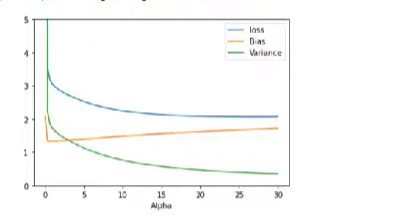

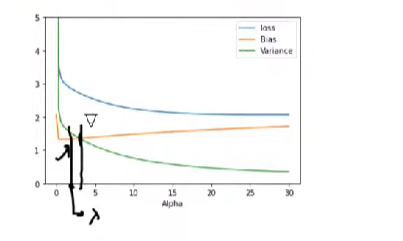

## 4. Effect of Regularization on Loss Function

- So the question is that jese jese $\lambda$ value ko increase karte hain, to loss function k saath kya hota hai?

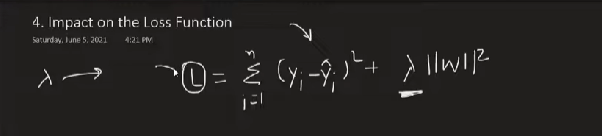

- For ease lets take 1-dimensional input, and b= 0, so the loss function is $L(m) = (y - mx)^2 + \lambda m^2$. (The loss funcion is only function of m)

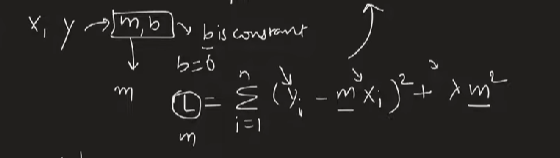

- Now we will change the value of $\lambda$ and see how the loss function is changing, as we increase the value of $\lambda$

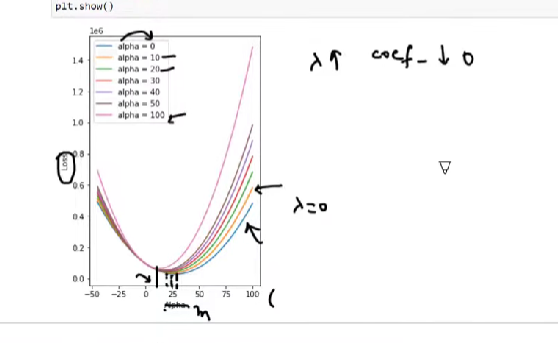

- So, the loss function starts shifting upwards in y-axis as we increase the value of $\lambda$ (which means, earlier if the model was overfitting then loss was less so as we regularize the model starts to simplify and hence increases the loss)

- The minimum point of the loss function is also shifting towards zero (x-axis), which means the optimal value of m is also decreasing as we increase the value of $\lambda$.

- As $\lambda$ increases, the loss function becomes more sharply curved (steeper), indicating stronger penalization of large parameter values.

[27.82809103]
-2.29474455867698


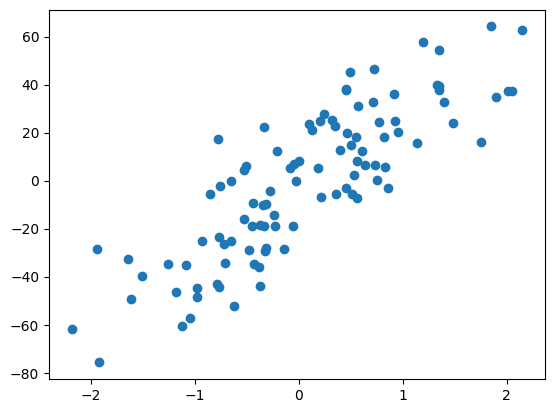

In [32]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [33]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [34]:
def predict(m):
    return m*X - 2.29

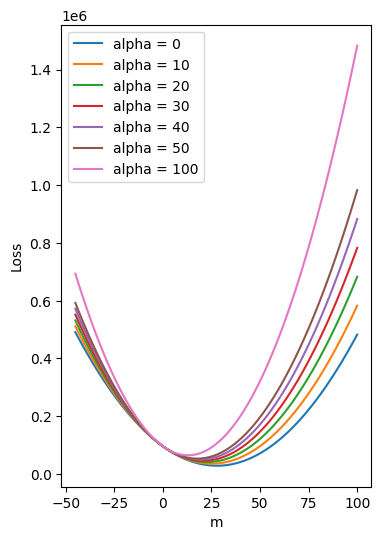

In [36]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('m')
plt.ylabel('Loss')
plt.show()

### for 2 coefficients
<img src='https://explained.ai/regularization/images/lagrange-animation.gif'>

# Why is it called Ridge?

- The loss function of Ridge regression have 2 terms, the first term is **MSE loss** and the second term is the **L2 Norm** of the weight vector.

- If you plot both the terms:
    - The L2 norm will be a circle (in 2D) or a sphere (in higher dimensions).
    {the radius of the circle is found using hyperparameter tuning to fix the constraint}
    - The MSE loss will be a bowl-shaped function (elliptical contours in 2D).

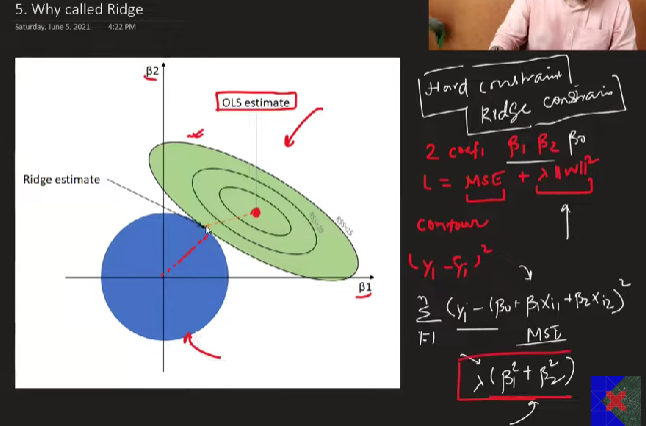

- In the above pic you can see that , if you didn't apply regularization, then the center of the elliptical contours (which is the optimal solution) would be at the point where the MSE loss is minimum

- <span style="color:orange"> **But now you want to minimize both the MSE loss and the L2 norm, so the optimal solution will be at the point where the elliptical contours first touch the circle (L2 norm constraint).** </span>

- And since the solution is always on the periphery/ridge of the circle, so it is called Ridge regression.

# Practical Tip

1. Apply ridge regression only when **number of features  $>= 2$**

    - As, jitne number of features honge, utne hi weights ko regularize karna hoga, aur Ridge regression me jitne weights honge, utne hi regularization term add hoga, so it is more effective when we have more features.